In [11]:
from cellarium.ml import CellariumAnnDataDataModule, CellariumModule
from cellarium.ml.data import read_h5ad_file
from cellarium.ml.data import DistributedAnnDataCollection
from cellarium.ml.utilities.data import AnnDataField, collate_fn, densify, categories_to_codes
from cellarium.ml.callbacks import PredictionWriter
from cellarium.ml.data.dadc_dataset import IterableDistributedAnnDataCollectionDataset
from cellarium.ml.models import ImputationModel_Annealing, ImputationModel

import lightning.pytorch as pl
from lightning.pytorch.loggers import CSVLogger
import pandas as pd
import numpy as np
import anndata as ad
import glob
import os
import torch
import matplotlib.pyplot as plt
import scanpy as sc
import scipy.sparse as sp
import seaborn as sns
import shutil
import pickle
import random

from sklearn.model_selection import train_test_split
from cellarium.ml.data.fileio import read_h5ad_file

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

import utils


### CellariumAnnDataDataModule for 10k pbmc count data

In [12]:
data_path = "/Users/aseelawdeh/Documents/stephen_scvi/pbmc_count.h5ad"
adata = read_h5ad_file(data_path)

dm = CellariumAnnDataDataModule(
            dadc = adata,
            batch_keys={
                "x_ng": AnnDataField(attr="raw.X", convert_fn=densify),
                "var_names_g": AnnDataField(attr="var_names"),
                "obs_names_n": AnnDataField(attr="obs_names"),
                "batch_index_n": AnnDataField(attr="obs", key="batch",convert_fn=categories_to_codes) # line set it up so that we iterate
                },
            batch_size=512,
            shuffle=False,
            #shuffle_seed=0
        )

In [ ]:
adata.obs["batch"].value_counts() 

batch
10X               10393
Oetjen_U           3668
Freytag            3347
Oetjen_P           3243
Oetjen_A           2535
Sun_sample4_TC     2387
Sun_sample3_TB     2322
Sun_sample2_KC     2175
Sun_sample1_CS     1704
Name: count, dtype: int64

In [ ]:
# Train imputation models with different masking probabilities and save predictions in separate folder
masking_prob = 0.5
max_annealing_weights = [0.05, 0.2, 0.5, 0.7, 0.9, 1]
schedule_types = ["cosine", "delayed_linear"]

for scheduler in schedule_types:
    print(f"\nStarting training with annealing schedule: {scheduler}")
    prediction_base= f'runs/imputation_annealing_schedule_{scheduler}'

    for weight in max_annealing_weights:
        print(f"\nProcessing max annealing weight: {weight}")
        prediction_base_path = f"{prediction_base}/mask{int(masking_prob*100)}_n2s{int(weight*100)}"
        os.makedirs(prediction_base_path, exist_ok=True)
        adata_run = adata.copy()

        # Define imputation module
        imputation_module = CellariumModule(
            model=ImputationModel_Annealing(
                var_names_g=dm.dadc.var_names,
                n_batch=10,
                n_latent=20,
                masking_probability=masking_prob,
                anneal_noise2self=True,
                noise2self_ratio_max=weight,
                noise2self_warmup_epochs=8,
                noise2self_schedule_type=scheduler,
                encoder={
                    "hidden_layers": [
                        {"class_path": "torch.nn.Linear", "init_args": {"out_features": 128}}
                    ],
                    "final_layer": {"class_path": "torch.nn.Linear", "init_args": {}},
                },
                decoder={
                    "hidden_layers": [
                        {"class_path": "torch.nn.Linear", "init_args": {"out_features": 128}}
                    ],
                    "final_layer": {"class_path": "torch.nn.Linear", "init_args": {}},
                    "final_additive_bias": False,
                },
                dropout_rate=0.1,
                dispersion="gene",
                log_variational=True,
                gene_likelihood="nb",
                latent_distribution="normal"
            ),
            optim_fn=torch.optim.AdamW,
            optim_kwargs={"lr": 1e-4}
        )

        # Train and get predictions for this masking probability
        # Predictions includes: "{name_label}_whole", "{name_label}_masked", "{name_label}_latent_whole", "{name_label}_latent_masked", "{name_label}_masked_gene_indices"
        predictions = utils.train_and_predict_imputation(imputation_module, adata_run, dm, masking_prob, weight, 
                                                        prediction_base_path=prediction_base_path,
                                                        epochs=20)
        # mask50_n2s90_masked
        latent_representation = predictions[f"mask{int(masking_prob*100)}_n2s{int(weight*100)}_latent_masked"]
        cell_labels = adata.obs["final_annotation"]

        # Split the data into training and testing sets (80% train, 20% test)
        X_train, X_test, y_train, y_test = train_test_split(latent_representation, cell_labels, test_size=0.2, random_state=42, stratify=cell_labels)

        # Train the classifiers
        lr_model, rf_model, svm_model = utils.train_classifiers(X_train=X_train, y_train=y_train)
                
        # Evaluate the classifiers
        metrics_df = utils.evaluate_classifiers(models=[lr_model, rf_model, svm_model], X_test=X_test, y_test=y_test, prob=masking_prob, noise2self_ratio=weight)
        metrics_df.to_csv(f"metrics_parameter_sweep/with_annealing/mask{int(masking_prob*100)}_n2s{int(weight*100)}_schedule_{scheduler}_parameter_sweep_metrics.csv", index=False)

### Combine metrics per masking prob per n2s together

In [ ]:
import pandas as pd 
import glob 

# Load all result files w/annealing cosine 
files = glob.glob("metrics_parameter_sweep/with_annealing/cosine/*.csv")
all_metrics = []
for file in files:
    df = pd.read_csv(file)
    all_metrics.append(df)
df_cosine = pd.concat(all_metrics, ignore_index=True)
print(df_cosine.head())

# Load all result files w/annealing delayed linear
files = glob.glob("metrics_parameter_sweep/with_annealing/delayed_linear/*.csv")
all_metrics = []
for file in files:
    df = pd.read_csv(file)
    all_metrics.append(df)
df_delayed_linear = pd.concat(all_metrics, ignore_index=True)
print(df_delayed_linear.head())

# Load all result files without annealing
files = glob.glob("metrics_parameter_sweep/without_annealing/*.csv")
all_metrics = []
for file in files:
    df = pd.read_csv(file)
    all_metrics.append(df)
df_without_annealing = pd.concat(all_metrics, ignore_index=True)
print(df_without_annealing.head())

  classifier  masking_prob  noise2self_ratio        cell_type  precision  \
0         LR           0.5               0.5    CD10+ B cells   0.945946   
1         LR           0.5               0.5  CD14+ Monocytes   0.957725   
2         LR           0.5               0.5  CD16+ Monocytes   0.714286   
3         LR           0.5               0.5    CD20+ B cells   0.984321   
4         LR           0.5               0.5     CD4+ T cells   0.807346   

     recall  f1_score  
0  0.853659  0.897436  
1  0.982650  0.970027  
2  0.217391  0.333333  
3  0.982609  0.983464  
4  0.978202  0.884600  
  classifier  masking_prob  noise2self_ratio        cell_type  precision  \
0         LR           0.5               0.2    CD10+ B cells   0.904762   
1         LR           0.5               0.2  CD14+ Monocytes   0.957692   
2         LR           0.5               0.2  CD16+ Monocytes   0.600000   
3         LR           0.5               0.2    CD20+ B cells   0.991228   
4         LR       

In [9]:
macro_noanneal = (
    df_without_annealing
    .groupby(["noise2self_ratio"])
    .agg(
        macro_precision=("precision", "mean"),
        macro_recall=("recall", "mean"),
        macro_f1=("f1_score", "mean"),
        n_cell_types=("cell_type", "nunique"),
    )
    .reset_index()
)

macro_linear = (
    df_delayed_linear
    .groupby(["noise2self_ratio"])
    .agg(
        macro_precision=("precision", "mean"),
        macro_recall=("recall", "mean"),
        macro_f1=("f1_score", "mean"),
        n_cell_types=("cell_type", "nunique"),
    )
    .reset_index()
)

macro_cosine = (
    df_cosine
    .groupby(["noise2self_ratio"])
    .agg(
        macro_precision=("precision", "mean"),
        macro_recall=("recall", "mean"),
        macro_f1=("f1_score", "mean"),
        n_cell_types=("cell_type", "nunique"),
    )
    .reset_index()
)


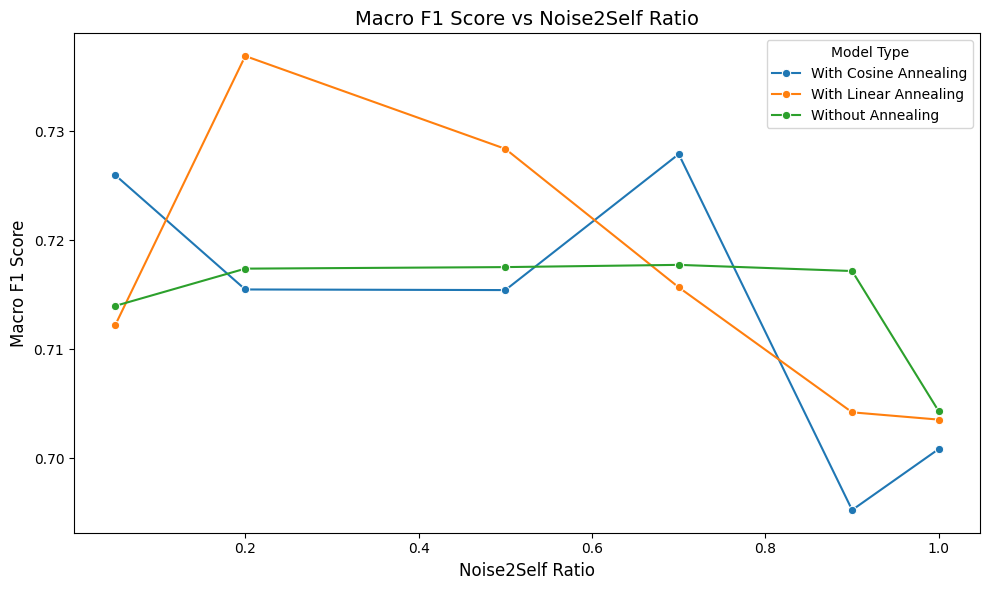

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(data=macro_cosine, x="noise2self_ratio", y="macro_f1", marker="o", label="With Cosine Annealing")
sns.lineplot(data=macro_linear, x="noise2self_ratio", y="macro_f1", marker="o", label="With Linear Annealing")
sns.lineplot(data=macro_noanneal, x="noise2self_ratio", y="macro_f1", marker="o", label="Without Annealing")
plt.xlabel("Noise2Self Ratio", fontsize=12)
plt.ylabel("Macro F1 Score", fontsize=12)
plt.title("Macro F1 Score vs Noise2Self Ratio", fontsize=14)
plt.legend(title="Model Type")
plt.tight_layout()
plt.show()